## CELL 1: KIỂM TRA METADATA HỆ THỐNG

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

%matplotlib inline
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
pd.set_option('display.max_columns', None)

input_path = "../data/raw/02_properties_house_raw.csv"
if not os.path.exists(input_path):
    raise FileNotFoundError(f"Không tìm thấy file: {input_path}. Hãy kiểm tra lại Pipeline chặng 2.")

df = pd.read_csv(input_path)
df = df.iloc[1:].reset_index(drop=True)
print("PHẦN 1 - CELL 1: KIỂM TRA METADATA HỆ THỐNG")
print(f"Kích thước ma trận dữ liệu: {df.shape[0]} dòng, {df.shape[1]} cột.")
print("\nCấu trúc kiểu dữ liệu của các đặc trưng (Data Types)")
print(df.info())

PHẦN 1 - CELL 1: KIỂM TRA METADATA HỆ THỐNG
Kích thước ma trận dữ liệu: 2542 dòng, 11 cột.

Cấu trúc kiểu dữ liệu của các đặc trưng (Data Types)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2542 entries, 0 to 2541
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   title            2542 non-null   object 
 1   price_raw        2542 non-null   float64
 2   area_raw         2542 non-null   float64
 3   address_raw      2542 non-null   object 
 4   url              2542 non-null   int64  
 5   bedrooms         1994 non-null   float64
 6   bathrooms        1882 non-null   float64
 7   floors           2186 non-null   float64
 8   house_direction  502 non-null    object 
 9   legal_status     2319 non-null   object 
 10  interior         1402 non-null   object 
dtypes: float64(5), int64(1), object(5)
memory usage: 218.6+ KB
None


## CELL 2: PHÂN TÍCH TOÀN VẸN VÀ KHUYẾT THIẾU

PHẦN 1 - CELL 2: PHÂN TÍCH TOÀN VẸN VÀ KHUYẾT THIẾU
Bảng thống kê chi tiết tỷ lệ khuyết thiếu trên từng biến:
                 Missing Values  Percentage (%)
house_direction            2040       80.251770
interior                   1140       44.846577
bathrooms                   660       25.963808
bedrooms                    548       21.557828
floors                      356       14.004721
legal_status                223        8.772620
title                         0        0.000000
price_raw                     0        0.000000
area_raw                      0        0.000000
address_raw                   0        0.000000
url                           0        0.000000


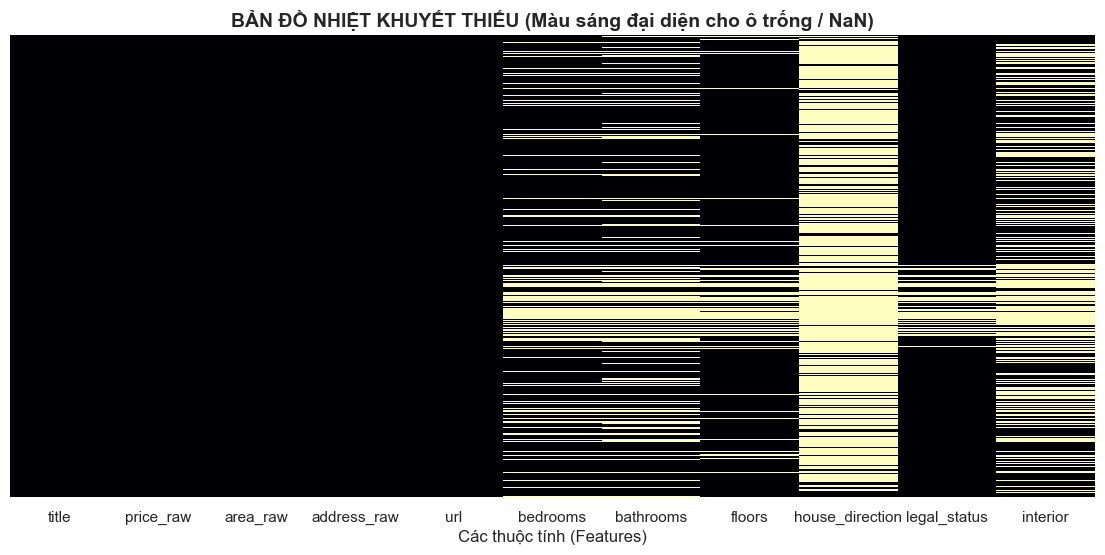

In [10]:
print("PHẦN 1 - CELL 2: PHÂN TÍCH TOÀN VẸN VÀ KHUYẾT THIẾU")

missing_count = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_table = pd.DataFrame({
    'Missing Values': missing_count,
    'Percentage (%)': missing_percent
}).sort_values(by='Percentage (%)', ascending=False)

print("Bảng thống kê chi tiết tỷ lệ khuyết thiếu trên từng biến:")
print(missing_table)

plt.figure(figsize=(14, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='magma', yticklabels=False)
plt.title('BẢN ĐỒ NHIỆT KHUYẾT THIẾU (Màu sáng đại diện cho ô trống / NaN)', fontsize=14, fontweight='bold')
plt.xlabel('Các thuộc tính (Features)')
plt.show()

Về quy mô mẫu: Lượng dữ liệu 2.542 dòng là rất tốt và hoàn toàn đủ dày để huấn luyện các thuật toán hồi quy ổn định.

Về kiểu dữ liệu (Dtype): Các cột cốt lõi quyết định giá (price_raw, area_raw, bedrooms, bathrooms, floors) đều đã ở dạng số (float64) chuẩn xác.

Vấn đề nghiêm trọng: Cột house_direction (Hướng nhà) chỉ có 502/2542 dòng có dữ liệu (tức là bị trống/NaN đến hơn 80%).

## CELL 3: PHÂN TÍCH BIẾN LIÊN TỤC

PHẦN 2 - CELL 3: PHÂN TÍCH BIẾN LIÊN TỤC

Thông số thống kê mô tả hình học số học:
         price_raw     area_raw
count  2542.000000  2542.000000
mean     16.512872    89.834397
std      28.188384    82.468238
min       0.980000     1.080000
25%       6.452500    50.000000
50%       8.900000    69.250000
75%      16.800000    99.500000
max     450.000000   896.000000

[PRICE_RAW]:
  - Độ lệch (Skewness): 7.9354
  - Độ nhọn (Kurtosis): 87.4066

[AREA_RAW]:
  - Độ lệch (Skewness): 4.4034
  - Độ nhọn (Kurtosis): 27.7621


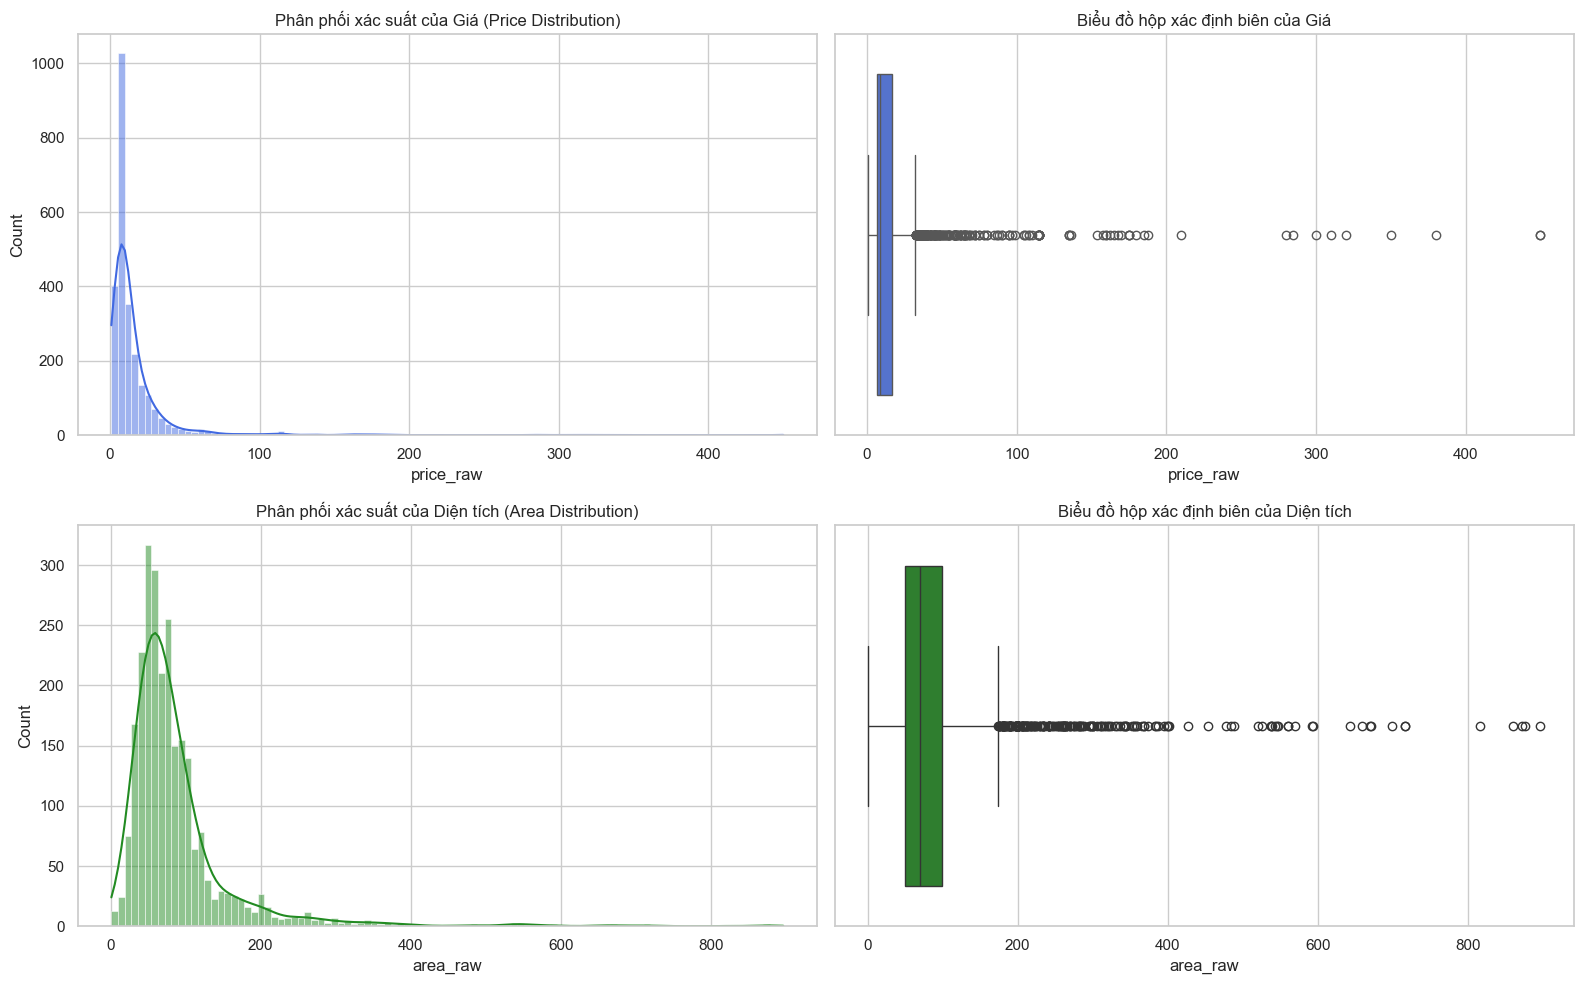

In [11]:
from scipy.stats import skew, kurtosis

print("PHẦN 2 - CELL 3: PHÂN TÍCH BIẾN LIÊN TỤC")
print("\nThông số thống kê mô tả hình học số học:")
print(df[['price_raw', 'area_raw']].describe())

# Tính toán toán học độ lệch và độ nhọn
for col in ['price_raw', 'area_raw']:
    print(f"\n[{col.upper()}]:")
    print(f"  - Độ lệch (Skewness): {skew(df[col].dropna()):.4f}")
    print(f"  - Độ nhọn (Kurtosis): {kurtosis(df[col].dropna()):.4f}")

# Vẽ phân phối xác suất hình học
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Price Dist
sns.histplot(df['price_raw'], kde=True, ax=axes[0, 0], color='royalblue')
axes[0, 0].set_title('Phân phối xác suất của Giá (Price Distribution)')
sns.boxplot(x=df['price_raw'], ax=axes[0, 1], color='royalblue')
axes[0, 1].set_title('Biểu đồ hộp xác định biên của Giá')

# Area Dist
sns.histplot(df['area_raw'], kde=True, ax=axes[1, 0], color='forestgreen')
axes[1, 0].set_title('Phân phối xác suất của Diện tích (Area Distribution)')
sns.boxplot(x=df['area_raw'], ax=axes[1, 1], color='forestgreen')
axes[1, 1].set_title('Biểu đồ hộp xác định biên của Diện tích')

plt.tight_layout()
plt.show()

Chỉ số Skewness của price_raw ($7.93$) và area_raw ($4.40$) cực kỳ cao, thể hiện rõ qua biểu đồ khi đuôi đồ thị kéo rất dài về bên phải. Đa số nhà riêng tập trung ở phân khúc bình dân (50% số nhà có giá dưới 8.9 tỷ và diện tích dưới $69.25m^2$), nhưng bị kéo lệch bởi các siêu biệt thự (Max lên tới 450 tỷ và $896m^2$).

Bắt buộc phải Log-transform (np.log1p) cả 2 biến này ở chặng sau.

Cột area_raw có giá trị nhỏ nhất là $1.08m^2$ (với giá Min của price_raw là $0.98$ tỷ). Không có căn nhà riêng thực tế nào diện tích chỉ $1m^2$ mà giá gần 1 tỷ. Đây chắc chắn là lỗi gõ nhầm diện tích hoặc tin rác.

Phần râu phía bên phải của cả 2 biểu đồ hộp xuất hiện các chấm tròn đen kéo dài liên tục, không đứt đoạn. Điều này chứng tỏ đây không phải là vài điểm dị biệt ngẫu nhiên, mà là sự xuất hiện của một phân khúc cao cấp hẳn (biệt thự/nhà mặt phố lớn) có phân phối khác biệt so với nhà trong ngõ hẻm.

## CELL 4: THỐNG KÊ TẦN SUẤT BIẾN DANH MỤC

In [20]:
print("CELL 4.1: TẦN SUẤT BIẾN FLOORS (SỐ TẦNG)")
print(df['floors'].value_counts(dropna=False))

CELL 4.1: TẦN SUẤT BIẾN FLOORS (SỐ TẦNG)
floors
4.0     626
2.0     571
3.0     473
NaN     356
5.0     274
1.0     125
6.0      69
7.0      30
8.0      10
9.0       6
10.0      2
Name: count, dtype: int64


In [21]:
print("CELL 4.2: TẦN SUẤT BIẾN BEDROOMS (PHÒNG NGỦ)")
print(df['bedrooms'].value_counts(dropna=False))

CELL 4.2: TẦN SUẤT BIẾN BEDROOMS (PHÒNG NGỦ)
bedrooms
4.0     574
NaN     548
3.0     428
2.0     327
5.0     255
6.0     138
7.0      55
1.0      48
8.0      41
9.0      23
10.0     18
15.0     13
11.0     11
12.0      9
13.0      9
20.0      8
16.0      5
14.0      4
17.0      4
28.0      4
30.0      3
23.0      3
18.0      2
19.0      1
27.0      1
25.0      1
80.0      1
46.0      1
52.0      1
93.0      1
22.0      1
34.0      1
21.0      1
65.0      1
26.0      1
Name: count, dtype: int64


In [22]:
print("CELL 4.3: TẦN SUẤT BIẾN BATHROOMS (PHÒNG TẮM)")
print(df['bathrooms'].value_counts(dropna=False))

CELL 4.3: TẦN SUẤT BIẾN BATHROOMS (PHÒNG TẮM)
bathrooms
NaN     660
2.0     399
5.0     367
3.0     362
4.0     305
6.0     137
1.0      89
7.0      68
8.0      41
9.0      24
10.0     17
11.0      9
13.0      9
12.0      8
15.0      8
20.0      6
16.0      6
14.0      4
17.0      4
21.0      2
29.0      2
18.0      2
22.0      2
30.0      2
52.0      1
28.0      1
25.0      1
80.0      1
47.0      1
34.0      1
65.0      1
26.0      1
23.0      1
Name: count, dtype: int64


In [23]:
print("CELL 4.4: TẦN SUẤT BIẾN HOUSE_DIRECTION (HƯỚNG NHÀ)")
print(df['house_direction'].value_counts(dropna=False))

CELL 4.4: TẦN SUẤT BIẾN HOUSE_DIRECTION (HƯỚNG NHÀ)
house_direction
NaN           2040
Đông - Nam     100
Tây - Nam       71
Nam             59
Tây             59
Tây - Bắc       55
Bắc             53
Đông            53
Đông - Bắc      52
Name: count, dtype: int64


In [24]:
print("CELL 4.5: TẦN SUẤT BIẾN LEGAL_STATUS (PHÁP LÝ)")
print(df['legal_status'].value_counts(dropna=False))

CELL 4.5: TẦN SUẤT BIẾN LEGAL_STATUS (PHÁP LÝ)
legal_status
Sổ đỏ/ Sổ hồng                                             1923
NaN                                                         223
Sổ hồng                                                     138
Có sổ                                                        64
Sổ hồng riêng                                                53
Sổ đỏ                                                        49
Sổ đỏ/ Sổ hồng                                           17
Sổ đỏ/sổ hồng                                                10
Sổ đỏ chính chủ                                               7
Sổ hồng chính chủ                                             7
Hợp đồng mua bán                                              5
Sổ vuông đẹp                                                  4
Sổ đỏ/ Sổ hồng sdc                                            4
Sổ đỏ/ Sổ hồng ( sử dụng chung)                               3
HDMB                                        

In [25]:
print("CELL 4.6: TẦN SUẤT BIẾN INTERIOR (NỘI THẤT)")
with pd.option_context('display.max_rows', None):
    print(df['interior'].value_counts(dropna=False))

CELL 4.6: TẦN SUẤT BIẾN INTERIOR (NỘI THẤT)
interior
NaN                                                                                                                                                                              1140
Đầy đủ                                                                                                                                                                            748
Cơ bản                                                                                                                                                                            353
Không nội thất                                                                                                                                                                     69
Đầy đủ.                                                                                                                                                                            64
Cơ bản.                              

Biến số học (**floors, bedrooms, bathrooms**) – Bẫy Outlier và bẫy NaN.

Lượng khuyết thiếu (NaN) rất lớn (từ 356 đến 660 dòng).

Xuất hiện các con số cực kỳ vô lý ở phần đuôi (...): Có nhà riêng có tận 28, 30 phòng ngủ; có nhà có tới 26, 65 phòng tắm. Đây đa phần là chung cư mini, nhà trọ cấu trúc nhiều phòng cho thuê, hoặc người nhập liệu gõ nhầm diện tích vào ô số phòng. Cần đặt ngưỡng cắt Outlier (ví dụ: số phòng ngủ $> 10$ là loại bỏ) để tránh làm lệch mô hình hồi quy.

Việc điền khuyết NaN sẽ tối ưu nếu dùng thuật toán (như KNN Imputer) dựa trên mối tương quan giữa diện tích và số tầng.

Biến **Hướng nhà** (house_direction): Khuyết nặng nhất hệ thống (2040/2542 dòng là NaN). Các nhãn còn lại (Đông - Nam, Tây - Nam...) phân bố khá đều và sạch.

Không thể xóa 2040 dòng này vì sẽ mất 80% dữ liệu. Giải pháp bắt buộc là biến NaN thành một nhóm riêng tên là "Không rõ" (Unknown). Mô hình Machine Learning sẽ coi "Không rõ" là một trạng thái hướng hợp lệ.

Biến **Pháp lý** (legal_status) – Rác văn bản (Text Noise): ản chất người bán chỉ muốn nói là nhà Có sổ hoặc Chưa có sổ (Hợp đồng mua bán). Nhưng vì họ gõ tự do nên đẻ ra hàng chục biến thể lặp lại: Sổ đỏ/ Sổ hồng, Sổ hồng riêng, Sổ đỏ chính chủ, Sổ đỏ/sổ hồng (gõ thường), Sổ vuông đẹp...

Bắt buộc phải dùng hàm .map() hoặc .replace() bằng Dict để gom tất cả 69 biến thể này về đúng 3 nhóm chuẩn: Sổ hồng/Sổ đỏ (Gom tất cả các loại sổ hồng, sổ đỏ, sổ riêng, chính chủ), Hợp đồng mua bán/Chưa sổ (Gom HDMB, Hợp đồng mua bán...), Không rõ (Thay cho các giá trị NaN).

Biến **Nội thất** (interior) – Lỗi dấu chấm và từ đồng nghĩa: Giống cột pháp lý, bị chia năm xẻ bảy do lỗi gõ dấu chấm hoặc từ viết tắt: Đầy đủ vs Đầy đủ. (có dấu chấm), Full vs Full., Cơ bản vs Cơ bản., Full NT...

Dùng String trimm và ép viết thường để dọn sạch. Sau đó gom tất cả về đúng 4 nhãn mang tính thang đo: Thô, không nội thất, cơ bản, đầy đủ, không rõ.


## CELL 5: MA TRẬN TƯƠNG QUAN

PHẦN 3 - CELL 5: MA TRẬN TƯƠNG QUAN


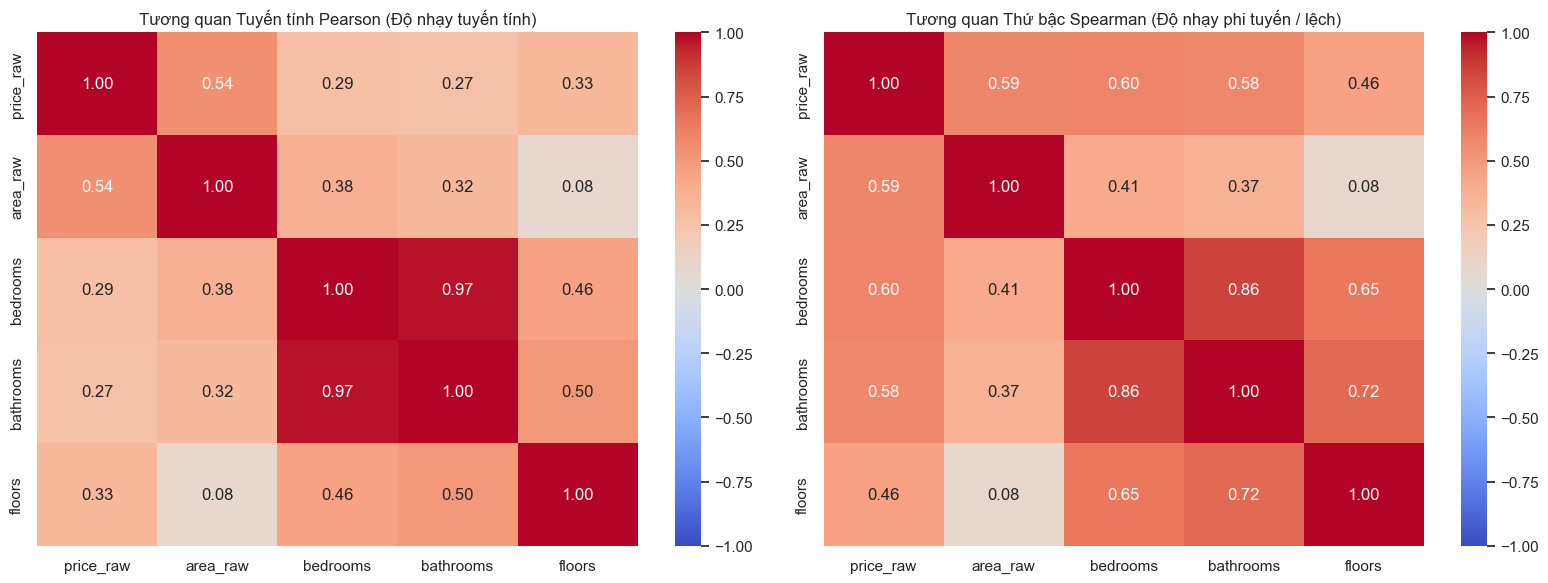

In [26]:
print("PHẦN 3 - CELL 5: MA TRẬN TƯƠNG QUAN")

numeric_features = df[['price_raw', 'area_raw', 'bedrooms', 'bathrooms', 'floors']]

# Tính toán song song 2 hệ số tương quan tuyến tính (Pearson) và phi tuyến (Spearman)
pearson_corr = numeric_features.corr(method='pearson')
spearman_corr = numeric_features.corr(method='spearman')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(pearson_corr, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, ax=axes[0])
axes[0].set_title('Tương quan Tuyến tính Pearson (Độ nhạy tuyến tính)')

sns.heatmap(spearman_corr, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, ax=axes[1])
axes[1].set_title('Tương quan Thứ bậc Spearman (Độ nhạy phi tuyến / lệch)')

plt.tight_layout()
plt.show()

Hệ số tương quan Pearson giữa bedrooms (phòng ngủ) và bathrooms (phòng tắm) lên tới $0.97$ (và Spearman là $0.86$).

Ý nghĩa khoa học: Hai biến này gần như là một. Chúng chứa lượng thông tin trùng lặp tới 97%.

Nếu đem cả 2 biến này vào train các mô hình tuyến tính (Linear Regression) toán từ scratch, ma trận toán học sẽ bị suy biến, các trọng số ($w$) sẽ nhảy loạn xạ và mất kiểm soát.

Ở bước Feature Engineering, bạn bắt buộc phải xử lý đa cộng tuyến bằng cách: hoặc là chỉ chọn giữ lại 1 trong 2 biến, hoặc gộp chúng lại thành một biến phái sinh duy nhất (ví dụ: total_rooms hoặc tỉ lệ bed_per_bath).

Hệ số tuyến tính Pearson của bedrooms với giá chỉ là $0.29$, bathrooms là $0.27$. (Cảm giác tương quan rất yếu).

Nhưng sang hệ số thứ bậc Spearman (nhạy với dữ liệu lệch và phi tuyến), độ tương quan của bedrooms vọt lên $0.60$ và bathrooms vọt lên $0.58$.

Ý nghĩa khoa học: Bản chất số phòng ngủ/phòng tắm tương quan rất mạnh với giá nhà. Nhưng do dữ liệu thô của bạn đang bị các Outlier siêu lớn (các căn biệt thự trăm tỷ) kéo lệch quá nặng, làm hệ số Pearson bị tính toán sai lệch (bị mù quáng).

Kết luận: Con số Spearman $0.60$ này chính là bằng chứng đanh thép nhất khẳng định: Chắc chắn phải Log-transform dữ liệu để đưa về phân phối chuẩn. Sau khi Log-transform xong, hệ số Pearson sẽ tự động đẹp và tăng vọt lên y như Spearman.

## CELL 6: PHÂN TÍCH TÁC ĐỘNG PHÁP LÝ

PHẦN 3 - CELL 6: PHÂN TÍCH TÁC ĐỘNG PHÁP LÝ


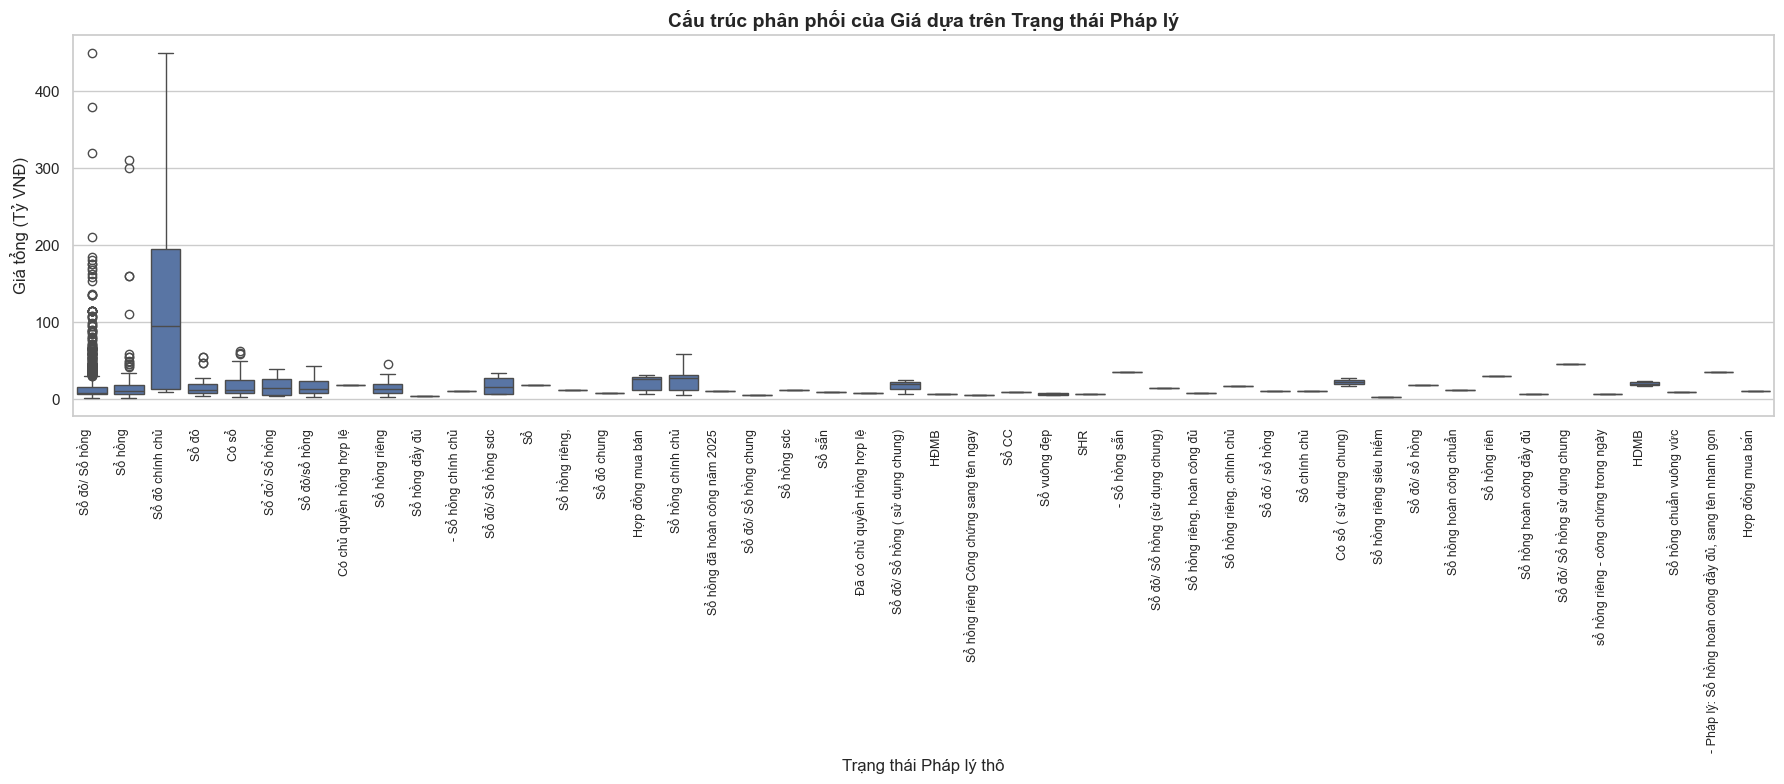

In [29]:
print("PHẦN 3 - CELL 6: PHÂN TÍCH TÁC ĐỘNG PHÁP LÝ")

plt.figure(figsize=(18, 8)) # Mở rộng chiều ngang ra 18 để có không gian cho các cột
sns.boxplot(x='legal_status', y='price_raw', data=df)

plt.title('Cấu trúc phân phối của Giá dựa trên Trạng thái Pháp lý', fontsize=14, fontweight='bold')
plt.xlabel('Trạng thái Pháp lý thô')
plt.ylabel('Giá tổng (Tỷ VNĐ)')

# XOAY NGƯỢC CHỮ ĐỨNG DỌC 90 ĐỘ ĐỂ KHÔNG BỊ ĐÈ NHAU
plt.xticks(rotation=90, ha='right', fontsize=9) 

plt.tight_layout() # Ép giao diện tự động tối ưu không mất chữ ở rìa
plt.show()

Nhìn từ trái qua phải, đồ thị bị kéo dài vô tận bởi hàng chục cột đơn lẻ. Bản chất các nhãn như Sổ đỏ/ Sổ hồng, Sổ hồng, Sổ đỏ, Có sổ, Sổ hồng riêng... đều cùng ý nghĩa pháp lý là Đã có giấy chứng nhận. Việc người dùng gõ tự do đã làm phân rã một biến phân loại đáng lẽ rất mạnh thành những mảnh vụn vặt, khiến mô hình không thể học được quy luật chung.

Nhóm thiểu số (Các đường gạch ngang bên phải): Hơn 80% số cột ở phía bên phải đồ thị chỉ là một đường thẳng dẹt dí. Điều này chứng tỏ các nhóm này chỉ có đúng 1-2 dòng dữ liệu (ví dụ: "Sổ hồng hoàn công đầy đủ...", "sổ hồng chuẩn vuông vức").

Nhóm đa số (Các hộp lớn bên trái): Lượng dữ liệu khổng lồ tập trung hoàn toàn vào 3 cột đầu tiên (Sổ đỏ/ Sổ hồng, Sổ hồng, Sổ đỏ chính chủ).

Hộp Sổ đỏ chính chủ (cột thứ 3) có thân hộp rất cao và râu kéo dài lên mốc 450 tỷ. Nhãn mang tính khẳng định này thường gắn liền với các bất động sản giá trị cao, diện tích lớn ở trung tâm.

Ngược lại, các nhãn như Sổ đỏ/ Sổ hồng (cột 1) và Sổ hồng (cột 2) tuy giá trung vị thấp (thân hộp nằm sát đáy) nhưng lại có mật độ chấm tròn Outlier dày đặc nhất. Điều này cho thấy phân khúc nhà phố thông thường có sổ hợp pháp chiếm số lượng áp đảo.

## CELL 6.2: ĐỒNG BỘ HÓA 22 QUẬN/HUYỆN TP.HCM VÀ GIÁ NHÀ

PHẦN 3 - CELL 6.2: ĐỒNG BỘ HÓA 22 QUẬN/HUYỆN TP.HCM VÀ GIÁ NHÀ
Bảng tần suất 22 Quận/Huyện sau khi chuẩn hóa linh hoạt:
district_clean
Quận Bình Thạnh      492
Quận 1               184
Quận 7               184
Quận Phú Nhuận       169
Quận Gò Vấp          163
TP. Thủ Đức          146
Quận 12              144
Quận Tân Bình        142
Huyện Nhà Bè         131
Quận Tân Phú         122
Quận 2               113
Quận 10              112
Khác / Ngoại tỉnh    104
Quận 3                91
Quận 9                71
Quận 8                37
Quận 5                35
Quận 11               23
Quận 4                22
Huyện Bình Chánh      20
Quận 6                16
Huyện Hóc Môn         13
Huyện Củ Chi           6
Huyện Cần Giờ          2
Name: count, dtype: int64




C:\Users\Acer\AppData\Local\Temp\ipykernel_4292\276050177.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='district_clean', y='price_raw', data=df_filtered_geo, order=existing_order, palette='Set3')


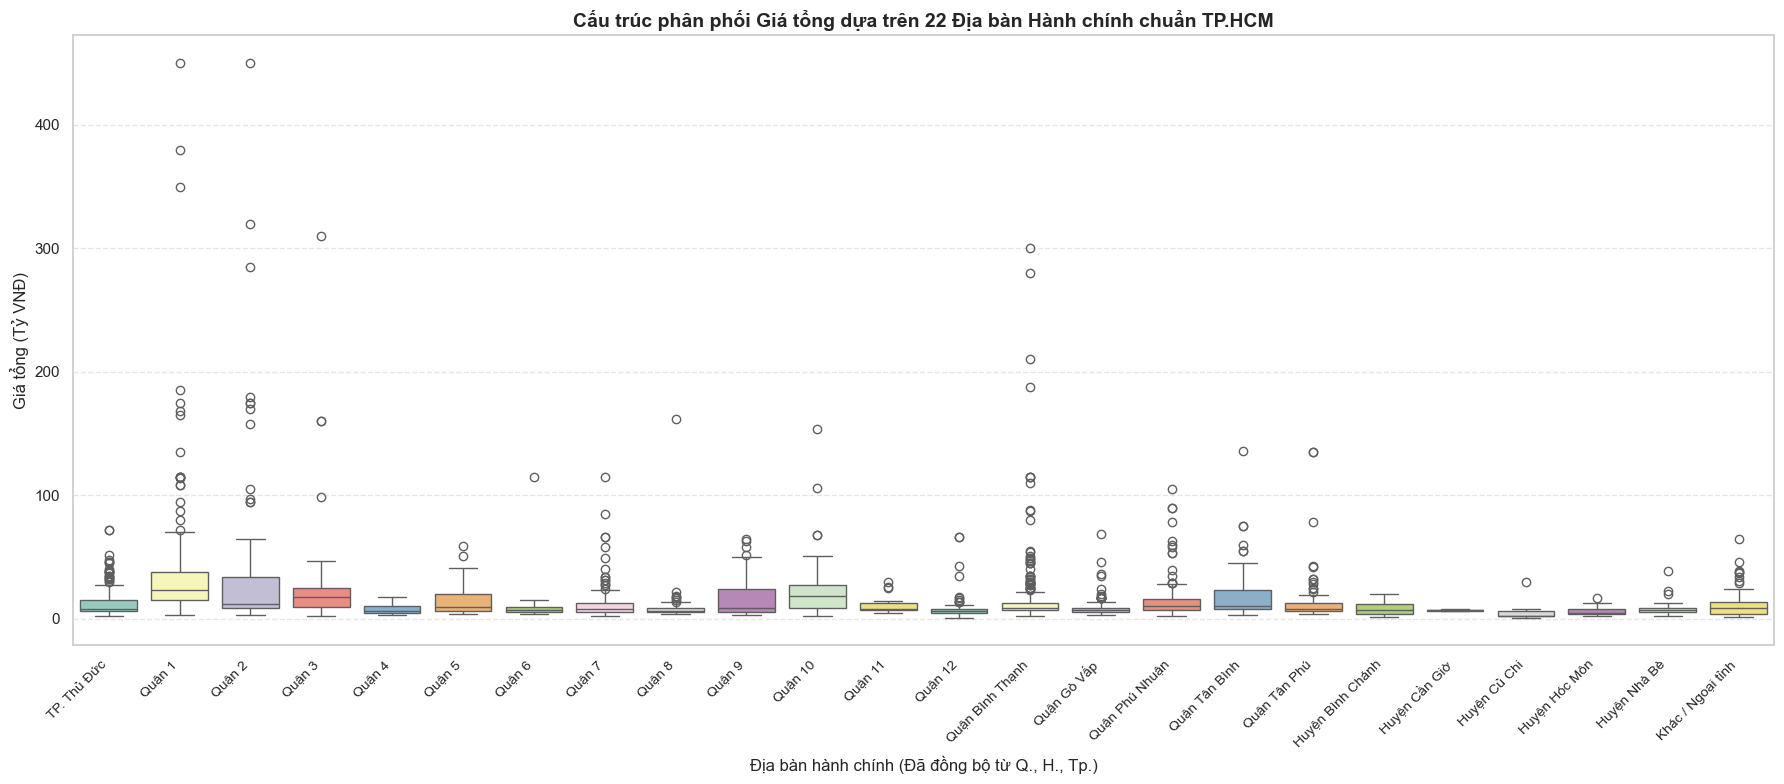

In [35]:
print("PHẦN 3 - CELL 6.2: ĐỒNG BỘ HÓA 22 QUẬN/HUYỆN TP.HCM VÀ GIÁ NHÀ")

import re
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def extract_district_flexible(address):
    if pd.isna(address):
        return 'Không rõ'
    
    addr_lower = str(address).lower().strip()
    
    # 1. Nhóm Thành phố / Huyện (Bắt cả chữ đầy đủ và viết tắt Tp., H., Huyện)
    if 'thủ đức' in addr_lower: return 'TP. Thủ Đức'
    if 'bình chánh' in addr_lower: return 'Huyện Bình Chánh'
    if 'cần giờ' in addr_lower: return 'Huyện Cần Giờ'
    if 'củ chi' in addr_lower: return 'Huyện Củ Chi'
    if 'hóc môn' in addr_lower: return 'Huyện Hóc Môn'
    if 'nhà bè' in addr_lower: return 'Huyện Nhà Bè'
    
    # 2. Nhóm Các Quận viết bằng Chữ (Bắt cả Q., Quận, viết thiếu)
    if 'bình thạnh' in addr_lower or 'q. bình' in addr_lower: return 'Quận Bình Thạnh'
    if 'bình tân' in addr_lower: return 'Quận Bình Tân'
    if 'gò vấp' in addr_lower or 'q. gò' in addr_lower: return 'Quận Gò Vấp'
    if 'phú nhuận' in addr_lower or 'q. phú' in addr_lower: return 'Quận Phú Nhuận'
    if 'tân bình' in addr_lower: return 'Quận Tân Bình'
    if 'tân phú' in addr_lower: return 'Quận Tân Phú'
    
    # 3. Nhóm Các Quận viết bằng Số (Quận 1 đến Quận 12)
    match_num = re.search(r'(?:quận|q\.?)\s*([0-9]+)', addr_lower)
    if match_num:
        num = int(match_num.group(1))
        if 1 <= num <= 12:
            return f"Quận {num}"
            
    # 4. Fallback phòng hờ cho dữ liệu rác không xác định được
    return 'Khác / Ngoại tỉnh'

df_eda_geo = df.copy()
df_eda_geo['district_clean'] = df_eda_geo['address_raw'].apply(extract_district_flexible)

print("Bảng tần suất 22 Quận/Huyện sau khi chuẩn hóa linh hoạt:")
district_counts = df_eda_geo['district_clean'].value_counts()
print(district_counts)
print("\n")

plt.figure(figsize=(18, 8))

hcm_districts_order = [
    'TP. Thủ Đức', 'Quận 1', 'Quận 2', 'Quận 3', 'Quận 4', 'Quận 5', 'Quận 6', 
    'Quận 7', 'Quận 8', 'Quận 9', 'Quận 10', 'Quận 11', 'Quận 12', 
    'Quận Bình Tân', 'Quận Bình Thạnh', 'Quận Gò Vấp', 'Quận Phú Nhuận', 
    'Quận Tân Bình', 'Quận Tân Phú', 'Huyện Bình Chánh', 'Huyện Cần Giờ', 
    'Huyện Củ Chi', 'Huyện Hóc Môn', 'Huyện Nhà Bè', 'Khác / Ngoại tỉnh'
]

existing_order = [d for d in hcm_districts_order if d in district_counts.index]
df_filtered_geo = df_eda_geo[df_eda_geo['district_clean'].isin(existing_order)]

sns.boxplot(x='district_clean', y='price_raw', data=df_filtered_geo, order=existing_order, palette='Set3')

plt.title('Cấu trúc phân phối Giá tổng dựa trên 22 Địa bàn Hành chính chuẩn TP.HCM', fontsize=14, fontweight='bold')
plt.xlabel('Địa bàn hành chính (Đã đồng bộ từ Q., H., Tp.)')
plt.ylabel('Giá tổng (Tỷ VNĐ)')
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Phân bổ mật độ mẫu (Sample Distribution): Dữ liệu có sự tập trung cực kỳ cao tại Quận Bình Thạnh (492 mẫu), theo sau là Quận 1 và Quận 7 ($184$ mẫu). Các huyện ngoại thành (Củ Chi, Cần Giờ) lượng mẫu rất thưa thớt.

Mối tương quan với giá nhà: Vị trí địa lý phân hóa giá trị bất động sản rất mạnh. Khối quận trung tâm cốt lõi (Quận 1, Quận 2, Quận 3) có mặt bằng giá (trung vị và hộp IQR) cao vượt trội.

Hiện tượng siêu Outlier: Các căn nhà có giá đỉnh điểm (300 - 450 tỷ) tập trung hoàn toàn ở Quận 1, Quận 2 và Quận Bình Thạnh (đất vàng trung tâm và khu biệt thự VIP).

Chiến lược bóc tách: Chỉ trích xuất duy nhất cấp Quận/Huyện/Thành phố. Loại bỏ các thông tin quá chi tiết như Phường/Xã, Tên đường hay Số nhà để tránh bẫy quá nhiều chiều (High Cardinality) làm mô hình bị học vẹt (Overfitting) trên tập dữ liệu nhỏ.

Kỹ thuật thực hiện: Áp dụng hàm bộ lọc từ khóa kết hợp Regex (giống hàm extract_district_flexible vừa chạy) để vét sạch các kiểu gõ tắt Q., H., Tp. và ép về đúng danh sách 24 nhãn địa bàn chuẩn của TP.HCM.

Để tối ưu cho mô hình, 104 dòng dữ liệu thuộc nhóm 'Khác / Ngoại tỉnh' (chiếm 4% nhiễu) sẽ bị loại bỏ hoàn toàn khỏi tập dữ liệu. Biến địa bàn hành chính chuẩn sau đó được mã hóa Ordinal với các giá trị số nguyên liên tục từ 0 đến 22, tăng dần theo thứ tự mức giá trung vị (Median) thực tế từ biểu đồ: thấp nhất là Huyện Cần Giờ (nhận giá trị 0), lần lượt tăng qua các huyện/quận ngoại thành và đạt giá trị cao nhất tại Quận 1 (nhận giá trị 22).

## CELL 6.4: PHÂN TÍCH TƯƠNG QUAN BIẾN NỘI THẤT VÀ BIẾN MỤC TIÊU

PHẦN 3 - CELL 6.4: PHÂN TÍCH TƯƠNG QUAN BIẾN NỘI THẤT VÀ BIẾN MỤC TIÊU
Bảng tần suất biến Nội thất sau khi đồng bộ nhãn:
interior_clean
Không rõ (NaN)       1140
Đầy đủ nội thất       912
Nội thất cơ bản       393
Không nội thất         76
Khác / Thỏa thuận      14
Bàn giao thô            7
Name: count, dtype: int64




C:\Users\Acer\AppData\Local\Temp\ipykernel_4292\3729587569.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='interior_clean', y='price_raw', data=df_eda_interior, order=existing_interior_order, palette='Set2', width=0.5)


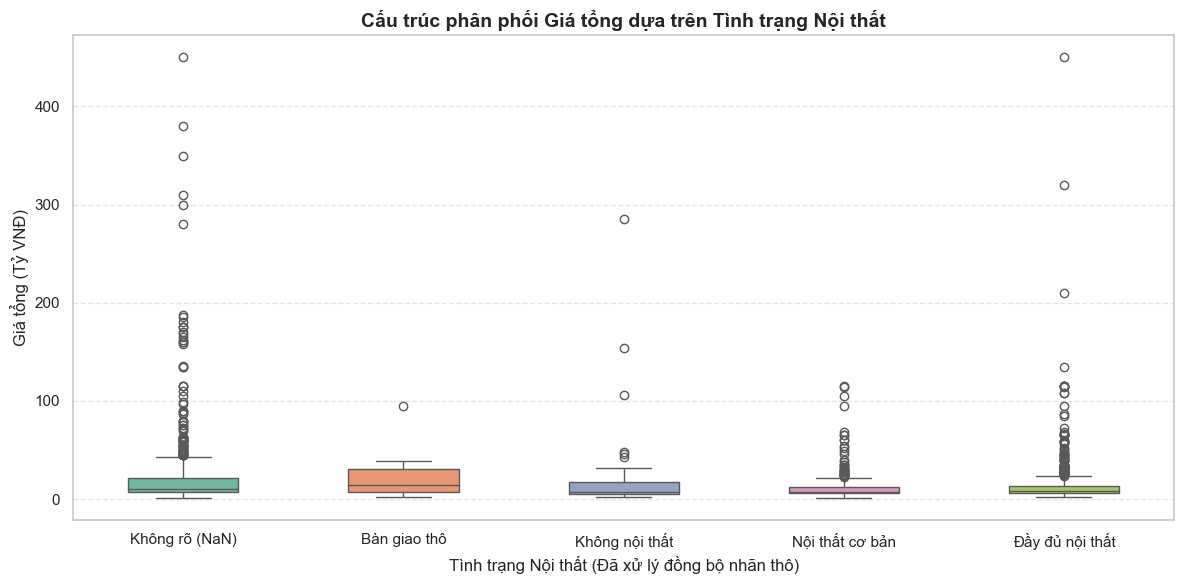

In [37]:
print("PHẦN 3 - CELL 6.4: PHÂN TÍCH TƯƠNG QUAN BIẾN NỘI THẤT VÀ BIẾN MỤC TIÊU")

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def extract_interior_clean(interior_text):
    if pd.isna(interior_text):
        return 'Không rõ (NaN)'
    
    int_lower = str(interior_text).lower().strip()
    
    # 1. Nhóm Đầy đủ / Full / Cao cấp
    if any(k in int_lower for k in ['đầy đủ', 'full', 'cao cấp', 'sang xịn', 'để lại nội thất']):
        return 'Đầy đủ nội thất'
        
    # 2. Nhóm Cơ bản
    if 'cơ bản' in int_lower:
        return 'Nội thất cơ bản'
        
    # 3. Nhóm Nhà trống / Không nội thất
    if 'không nội thất' in int_lower or 'nhà trống' in int_lower:
        return 'Không nội thất'
        
    # 4. Nhóm Bàn giao thô
    if 'thô' in int_lower:
        return 'Bàn giao thô'
        
    return 'Khác / Thỏa thuận'

df_eda_interior = df.copy()
df_eda_interior['interior_clean'] = df_eda_interior['interior'].apply(extract_interior_clean)

print("Bảng tần suất biến Nội thất sau khi đồng bộ nhãn:")
interior_counts = df_eda_interior['interior_clean'].value_counts()
print(interior_counts)
print("\n")

plt.figure(figsize=(12, 6))

interior_order = ['Không rõ (NaN)', 'Bàn giao thô', 'Không nội thất', 'Nội thất cơ bản', 'Đầy đủ nội thất']
existing_interior_order = [i for i in interior_order if i in interior_counts.index]

sns.boxplot(x='interior_clean', y='price_raw', data=df_eda_interior, order=existing_interior_order, palette='Set2', width=0.5)

plt.title('Cấu trúc phân phối Giá tổng dựa trên Tình trạng Nội thất', fontsize=14, fontweight='bold')
plt.xlabel('Tình trạng Nội thất (Đã xử lý đồng bộ nhãn thô)')
plt.ylabel('Giá tổng (Tỷ VNĐ)')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Nhóm Không rõ (NaN) chiếm vị trí quán quân tuyệt đối với 1.140 mẫu. Điều này chứng tỏ khi đăng tin bán nhà, hơn 40% người dùng hoàn toàn ngó lơ trường thông tin này.

Theo sau là nhóm Đầy đủ nội thất ($912$ mẫu) và Nội thất cơ bản ($393$ mẫu). Hai nhóm này cộng lại tạo nên khối lượng dữ liệu sạch có thể khai thác tốt ở chặng sau.

Thân hộp của nhóm Bàn giao thô lại dài hơn và cao hơn hẳn so với nhóm Nội thất cơ bản và Không nội thất.

Giải mã thực tế: Trong thị trường bất động sản, những căn nhà rao bán ở trạng thái "Bàn giao thô" hoặc "Không nội thất" thường rơi vào 2 trường hợp: một là nhà nát cũ kỹ ở trung tâm bán xác nhà (giá trị nằm ở đất vĩ mô), hai là các căn biệt thự/shophouse hạng sang mới xây thô chưa hoàn thiện nội thất của các dự án lớn. Chính vì vậy, giá tổng của chúng không hề rẻ, làm lệch hoàn toàn tư duy "nhà thô thì phải rẻ hơn nhà đầy đủ nội thất".

Các chấm tròn Outlier khủng (vọt lên mốc 300 - 450 tỷ) chỉ xuất hiện tập trung ở hai nhóm: Không rõ (NaN) và Đầy đủ nội thất.

Điều này chứng tỏ: Những căn siêu biệt thự trăm tỷ hoặc là được trang hoàng nội thất siêu sang (Full nội thất), hoặc là chủ nhà VIP/môi giới VIP chỉ đăng tin ngắn gọn, lười tick chọn trạng thái nội thất (NaN).

Gán nhãn Ordinal dựa trên chính thứ hạng giá trung vị (Median), dựa vào đường gạch giữa của các thân hộp trên hình, thứ tự mức giá trung vị từ thấp đến cao sẽ là: Nội thất cơ bản hoặc Không nội thất (Thấp nhất) thì mã hóa thành số 0 và 1, Không rõ (NaN) thì Mã hóa thành số 2, đầy đủ nội thất thì Mã hóa thành số 3, Bàn giao thô (Mặt bằng trung vị cao nhất) thì Mã hóa thành số 4.



## CELL 7: PHÂN TÍCH OUTLIER TOÁN HỌC

PHẦN 4 - CELL 7: PHÂN TÍCH OUTLIER TOÁN HỌC
Kết quả phân tích IQR cho Đơn giá (Tỷ/m²):
  - Biên dưới lý thuyết (Lower Bound): -0.047385
  - Biên trên lý thuyết (Upper Bound): 0.364924


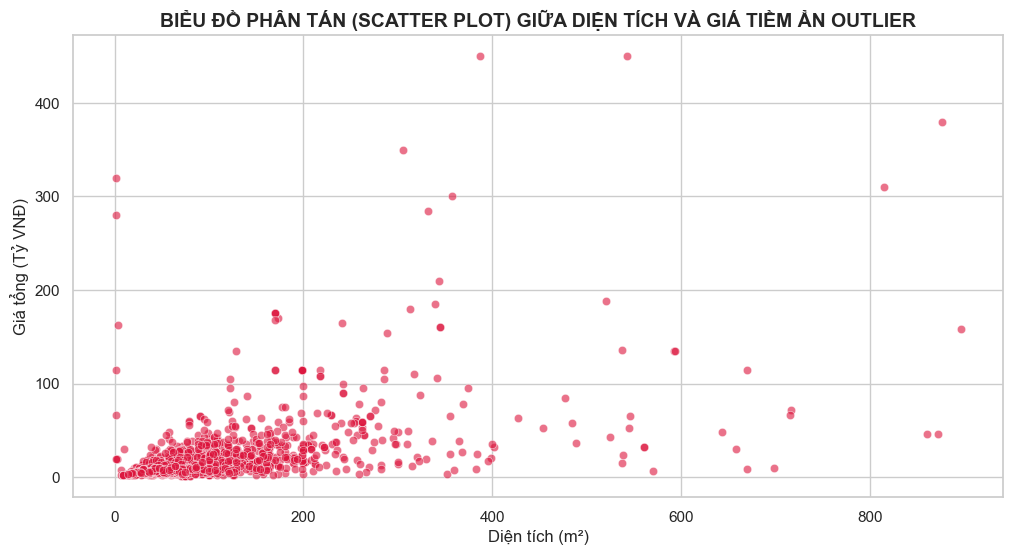


 Số lượng dòng Outlier vượt biên trên toán học: 176 dòng.

Chi tiết 10 dòng Outlier biên trên tiêu biểu:
        title  price_raw  area_raw  price_per_m2  \
18  Nhà riêng      115.0    285.17      0.403268   
19  Nhà riêng      105.0    122.60      0.856444   
28  Nhà riêng      115.0    198.60      0.579053   
29  Nhà riêng      160.0    344.00      0.465116   
33  Nhà riêng      210.0    343.00      0.612245   
40  Nhà riêng       39.0     82.00      0.475610   
41  Nhà riêng      108.0    217.40      0.496780   
48  Nhà riêng      154.0    288.00      0.534722   
49  Nhà riêng       41.0    100.00      0.410000   
67  Nhà riêng       27.0     65.00      0.415385   

                             address_raw  
18  P. Bình Lợi Trung (Q. Bình Thạnh cũ)  
19               P. An Khánh (Quận 2 cũ)  
28           P. Cầu Ông Lãnh (Quận 1 cũ)  
29               P. Xuân Hòa (Quận 3 cũ)  
33        P. Gia Định (Q. Bình Thạnh cũ)  
40             P. Diên Hồng (Quận 10 cũ)  
41           P. Cầu 

In [38]:
print("PHẦN 4 - CELL 7: PHÂN TÍCH OUTLIER TOÁN HỌC")

# Khởi tạo biến phái sinh Đơn giá phục vụ chẩn đoán
df['price_per_m2'] = df['price_raw'] / df['area_raw']

Q1 = df['price_per_m2'].quantile(0.25)
Q3 = df['price_per_m2'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Kết quả phân tích IQR cho Đơn giá (Tỷ/m²):")
print(f"  - Biên dưới lý thuyết (Lower Bound): {lower_bound:.6f}")
print(f"  - Biên trên lý thuyết (Upper Bound): {upper_bound:.6f}")

plt.figure(figsize=(12, 6))
sns.scatterplot(x='area_raw', y='price_raw', data=df, alpha=0.6, color='crimson')
plt.title('BIỂU ĐỒ PHÂN TÁN (SCATTER PLOT) GIỮA DIỆN TÍCH VÀ GIÁ TIỀM ẨN OUTLIER', fontsize=14, fontweight='bold')
plt.xlabel('Diện tích (m²)')
plt.ylabel('Giá tổng (Tỷ VNĐ)')
plt.show()

outliers_upper = df[df['price_per_m2'] > upper_bound]
print(f"\n Số lượng dòng Outlier vượt biên trên toán học: {len(outliers_upper)} dòng.")
if len(outliers_upper) > 0:
    print("\nChi tiết 10 dòng Outlier biên trên tiêu biểu:")
    print(outliers_upper[['title', 'price_raw', 'area_raw', 'price_per_m2', 'address_raw']].head(10))

Phần lớn dữ liệu (Mật độ tập trung): Đám đông các chấm hồng tụ hội cực kỳ dày đặc ở góc dưới bên trái (Diện tích $< 200m^2$ và Giá tổng $< 50$ tỷ). 

Công thức IQR báo có 176 dòng Outlier vượt ngưỡng biên trên $0.364$ Tỷ/$m^2$ (tương đương $> 364$ triệu/m²).

Nhìn vào danh sách sẽ thấy các căn nhà này nằm toàn bộ ở Quận 1, Quận 2, Quận 3, Quận 5, Quận 10, Bình Thạnh. Đơn giá của chúng dao động từ $400$ triệu đến hơn $850$ triệu/$m^2$.

Đây chính là giá trị thực tế của phân khúc nhà phố mặt tiền, đất vàng lõi trung tâm Sài Gòn.

Diện tích gần bằng 0 nhưng Giá tổng vọt lên hơn 100 - 300 tỷ) hoặc các chấm nằm cô độc ở rìa phải (Diện tích gần $900m^2$ nhưng giá cực kỳ thấp). Đây là rác do người dùng gõ thiếu hoặc thừa số 0.

Loại bỏ các căn nhà có diện tích quá phi lý, không đúng cấu trúc một căn nhà riêng/nhà phố: area_raw $< 10m^2$, area_raw $> 600m^2$.

Thay vì cắt ở ngưỡng $364$ triệu/$m^2$ của IQR (làm mất nhà Quận 1), chúng ta sẽ đặt một ngưỡng cắt cứng dựa trên thực tế thị trường cao cấp (Hard Thresholding):

Giữ lại dữ liệu có price_per_m2 $\le 1.0$ Tỷ/$m^2$ ($1$ tỷ/m²). Ngưỡng này vừa đủ bao quát toàn bộ các căn siêu VIP quận trung tâm trong danh sách.

Loại bỏ các căn có Giá tổng price_raw $> 400$ Tỷ.

## 📊 BẢNG TỔNG HỢP CHIẾN LƯỢC TIỀN XỬ LÝ TOÀN DIỆN CHO 11 BIẾN (CHỐT HẠ TỪ EDA)

Để chuẩn bị dữ liệu tối ưu cho các mô hình hồi quy và toán ma trận cấu trúc từ scratch (bằng NumPy), chiến lược tiền xử lý tại file 04 sẽ chia làm hai trục chính: **Xử lý đơn biến** (Dọn rác, lọc Outlier, mã hóa thứ bậc) và **Xử lý đa biến** (Khử hiện tượng đa cộng tuyến giữa Diện tích và hệ thống số Phòng).

| Tên biến | Đặc tính dữ liệu (Chứng minh qua biểu đồ EDA) | Giải pháp xử lý chính thức (Chuyển sang File 04) |
| :--- | :--- | :--- |
| **`title`** | - Tiêu đề chữ tự do do người dùng tự gõ.<br>- Chứa thông tin lặp, không có giá trị toán học hay tính chất định giá. Sau khi lọc và tách dữ liệu thì toàn bộ là NHà Riêng nên không có giá trị dự đoán | - **Xóa bỏ (Drop)** hoàn toàn cột này ngay đầu file Preprocessing để giải phóng bộ nhớ. |
| **`url`** | - Đường dẫn bài đăng, mang tính chất định danh duy nhất (Unique ID).<br>- Sau khi bóc tách để lọc ra tiêu đề thì không còn tác dụng dự báo. | - **Xóa bỏ (Drop)** hoàn toàn cột này cùng lúc với biến `title`. |
| **`address_raw`** | - Nhiễu chữ nặng, nhiều ký tự viết tắt (`Q.`, `H.`), viết thiếu (`Q. Bình`, `Q. Gò`).<br>- Mẫu tập trung cực lớn ở Bình Thạnh ($492$ mẫu), Quận 1, Quận 7.<br>- Nhóm `Khác / Ngoại tỉnh` chiếm 4% ($104$ mẫu) là rác dữ liệu làm lệch đường trung vị hệ thống. | - **Cắt lọc & Gom nhóm:** Dùng Regex và bộ lọc từ khóa ép chuỗi về đúng danh mục Quận/Huyện chuẩn.<br>- **Xóa nhiễu:** Thẳng tay **Xóa bỏ (Drop) 104 dòng** nhóm 'Khác / Ngoại tỉnh' để làm sạch tập dữ liệu 100%.<br>- **Mã hóa:** Dùng **Ordinal Encoding** (0 đến 22) sắp xếp tăng dần theo đúng thứ tự giá trung vị thực tế trên biểu đồ (Cần Giờ = 0, ..., Quận 1 = 22). |
| **`legal_status`** | - Chứa hơn 60 biến thể chữ tự do do người dùng nhập lập lờ.<br>- Nhóm có sổ chiếm áp đảo tuyệt đối (> 80%). Có tồn tại giá trị khuyết thiếu (`NaN`). | - **Gom nhóm:** Dọn sạch từ đồng nghĩa, ép về đúng 3 nhãn bản chất: `Có Sổ`, `Chưa Sổ / HDMB`, và nhãn `Không rõ` cho các dòng bị khuyết thiếu (`NaN`).<br>- **Mã hóa:** Dùng **Ordinal Encoding** (0, 1, 2) tăng dần theo độ an toàn pháp lý. |
| **`interior`** | - Dữ liệu chữ rất nát, dính lỗi dấu chấm cú pháp bừa bãi (`Đầy đủ.`, `Cơ bản.`).<br>- Nhóm khuyết thiếu `NaN` khổng lồ ($1.140$ mẫu, chiếm hơn 40%).<br>- Nghịch lý bất động sản: Nhóm `Bàn giao thô` có trung vị giá cao vọt do dính phân khúc biệt thự/shophouse hạng sang xây thô. | - **Tuyệt đối KHÔNG xóa cột**.<br>- **Gom nhóm:** Ép về 4 nhóm sạch và giữ nguyên nhãn `Không rõ` cho các dòng `NaN`.<br>- **Mã hóa:** Dùng **Ordinal Encoding** (0 đến 4) gán số tăng dần dựa theo đúng thứ hạng giá trung vị trên biểu đồ thực tế: *Cơ bản = 0, Không nội thất = 1, Không rõ = 2, Đầy đủ = 3, Bàn giao thô = 4*. |
| **`house_direction`** | - Hướng nhà (Đông, Tây, Nam, Bắc...).<br>- Lượng mẫu phân rải rác, không mang tính thứ bậc hay tuyến tính rõ ràng với biến mục tiêu. | - **Gom nhóm:** Đồng bộ hóa về các hướng chính và điền khuyết `NaN` thành `Không rõ`.<br>- **Mã hóa:** Dùng **One-Hot Encoding** (Bật `drop_first=True` để tránh bẫy Dummy) hoặc **Target Encoding** tùy thuộc vào độ thưa của mẫu. |
| **`bedrooms`** | - Biến số lượng phòng ngủ.<br>- **Nguy cơ đa cộng tuyến:** Tương quan tuyến tính cực cao với diện tích (`area_raw`).<br>- Xuất hiện một số giá trị khuyết thiếu (`NaN`) hoặc số phòng quá lớn phi lý do lỗi gõ phím. | - **Quy trình xử lý tích hợp khử đa cộng tuyến (Áp dụng chung cho nhóm biến Phòng):**<br>1. **Lọc Outlier & Khuyết thiếu trước:** Điền khuyết `NaN` bằng giá trị trung vị (**Median**). Tiến hành lọc bỏ Outlier vật lý rời rạc bám sát thực tế, chỉ giữ lại những căn nhà có số phòng từ $1 \le \text{bedrooms} \le 15$ phòng.<br>2. **Gộp biến đặc trưng (Feature Combination) sau khi lọc sạch:** Tiến hành gộp biến ngủ và vệ sinh thành tổng số phòng (`total_rooms` = `bedrooms` + `bathrooms`) để cô lập không gian, hoặc biến đổi thành dạng tỷ lệ mật độ diện tích (`area_per_bedroom` = `area_raw` / `bedrooms`).<br>3. **Quét lọc VIF (Variance Inflation Factor):** Kiểm tra độ phóng đại phương sai, nếu chỉ số $VIF > 10$, tiến hành loại bỏ biến gốc thừa thãi để tránh làm ma trận hiệp phương sai bị suy biến khi training model từ scratch. |
| **`bathrooms`** | - Biến số lượng phòng vệ sinh.<br>- Tương quan tuyến tính rất cao với diện tích và số phòng ngủ, dính lỗi khuyết thiếu tương tự. | - **Quy trình tương tự biến `bedrooms`:**<br>1. Điền khuyết `NaN` bằng giá trị **Median**.<br>2. Đặt ngưỡng lọc Outlier vật lý: Giới hạn từ $1 \le \text{bathrooms} \le 15$ phòng.<br>3. Đưa vào hàm gộp đặc trưng tạo biến tỷ lệ và cho qua bộ lọc VIF để loại bỏ đặc trưng đa cộng tuyến cao. |
| **`floors`** | - Biến số tầng của căn nhà.<br>- Chứa nhiều giá trị khuyết thiếu `NaN` (do đặc thù đất nền hoặc nhà trệt không có tầng). | - **Điền khuyết:** Điền giá trị `NaN` bằng số `1` (đại diện cho nhà trệt/nhà cấp 4) hoặc dùng giá trị yếu vị (**Mode**).<br>- Đặt ngưỡng lọc bỏ các giá trị phi lý (ví dụ: số tầng $> 15$ đối với nhà riêng thông thường). |
| **`area_raw`** | - Biến liên tục (Diện tích).<br>- Biểu đồ phân tán chỉ ra dữ liệu tập trung mạnh ở vùng $< 200m^2$. Xuất hiện rác nhập liệu phi lý (quá nhỏ hoặc quá lớn nằm cô độc). | - **Đặt ngưỡng lọc vật lý (Hard Thresholding):** Loại bỏ lỗi gõ thiếu/thừa số 0 từ web bằng cách chỉ giữ lại các căn nhà có diện tích nằm trong dải logic kinh tế: $10m^2 \le \text{area\_raw} \le 600m^2$. |
| **`price_raw`** | - Biến mục tiêu (Giá tổng). Phân hóa cực đoan.<br>- Xuất hiện các chấm siêu Outlier biệt thự trăm tỷ ở trung tâm và chấm lỗi sát trục tung. | - **Đặt ngưỡng lọc thực tế:** Không dùng công thức IQR cắt mù quáng làm mất phân khúc nhà VIP Quận 1. Đặt ngưỡng giữ lại các căn biệt thự/nhà phố cao cấp thật sự có giá tổng $\text{price\_raw} \le 400$ Tỷ VNĐ và ép điều kiện giá phải dương ($\text{price\_raw} > 0$). |